GridWorld1

In [12]:
import random
import time

# -------------------------------
# |(0,0)|(0,1)|(0,2)|(0,3)|(0,4)|
# |(1,0)|(1,1)|(1,2)|(1,3)|(1,4)|
# |(2,0)|(2,1)|(2,2)|(2,3)|(2,4)|
# |(3,0)|(3,1)|(3,2)|(3,3)|(3,4)|
# |(4,0)|(4,1)|(4,2)|(4,3)|(4,4)|
# -------------------------------


class GridWorld():
    def __init__(
            self,
            height=5, width=5,        # 격자판의 크기
            start_state=(0, 0),       # 시작 상태
            terminal_states=[(4, 4)], # 종료 상태
            transition_reward=0.0,    # 일반적인 상태 전이 보상
            terminal_reward=1.0,      # 종료 상태로 이동하는 행동 수행 
                                      # 때 받는 보상
            outward_reward=0.0,       # 미로 바깥으로 이동하는 행동 수행
                                      # 때 받는 보상 
            warm_hole_states=None     # 윔홀 정의
    ):
        self.__version__ = "0.0.1"

        # 그리드월드의 세로 길이
        self.HEIGHT = height

        # 그리드월드의 가로 길이
        self.WIDTH = width

        self.STATES = []
        self.num_states = self.WIDTH * self.HEIGHT

        for i in range(self.HEIGHT):
            for j in range(self.WIDTH):
                self.STATES.append((i, j))

        # 터미널 상태를 상태 집합에서 제거
        for state in terminal_states:     
            self.STATES.remove(state)

        self.current_state = None

        # 모든 가능한 행동
        self.ACTION_UP = 0
        self.ACTION_DOWN = 1
        self.ACTION_LEFT = 2
        self.ACTION_RIGHT = 3

        self.ACTIONS = [
            self.ACTION_UP,
            self.ACTION_DOWN,
            self.ACTION_LEFT,
            self.ACTION_RIGHT
        ]

        # UP, DOWN, LEFT, RIGHT
        self.ACTION_SYMBOLS = ["↑", "↓", "←", "→"] 

        self.NUM_ACTIONS = len(self.ACTIONS)
        
        # 시작 상태 위치
        self.START_STATE = start_state

        # 종료 상태 위치
        self.TERMINAL_STATES = terminal_states

        # 웜홀 상태 위치
        self.WARM_HOLE_STATES = warm_hole_states

        # 일반 상태 전이 수행에 대한 보상 값
        self.transition_reward = transition_reward

        # 종료 상태 전이 수행에 대한 보상 값
        self.terminal_reward = terminal_reward

        # 그리드월드 바깥으로 상태 전이 수행해 대한 보상 값
        self.outward_reward = outward_reward


    # 환경 초기화 작업: 에이전트의 현재 위치를 START_STATE로 설정
    def reset(self):
        self.current_state = self.START_STATE
        return self.current_state

    # 에이전트의 현재 위치를 state로 설정
    def moveto(self, state):
        self.current_state = state

    # 주어진 state 상태가 웜홀 상태이면 True 반환하고, 아니면 False 반환
    def is_warm_hole_state(self, state):
        i, j = state

        if self.WARM_HOLE_STATES is not None \
            and len(self.WARM_HOLE_STATES) > 0:
            for warm_hole_info in self.WARM_HOLE_STATES:
                warm_hole_state = warm_hole_info[0]
                if i == warm_hole_state[0] and j == warm_hole_state[1]:
                    return True
        return False

    # 주어진 웜홀 상태 state에 대하여 미리 정해져 있는 다음 상태 반환
    def get_next_state_warm_hole(self, state):
        i, j = state
        next_state = None

        for warm_hole_info in self.WARM_HOLE_STATES:
            warm_hole_state = warm_hole_info[0]
            warm_hole_prime_state = warm_hole_info[1]

            if i == warm_hole_state[0] and j == warm_hole_state[1]:
                next_state = warm_hole_prime_state
                break
        return next_state

    # 주어진 웜홀 상태 state에 대하여 미리 정해져 있는 보상 반환
    def get_reward_warm_hole(self, state):
        i, j = state
        reward = None

        for warm_hole_info in self.WARM_HOLE_STATES:
            warm_hole_state = warm_hole_info[0]
            warm_hole_reward = warm_hole_info[2]

            if i == warm_hole_state[0] and j == warm_hole_state[1]:
                reward = warm_hole_reward
                break

        return reward

    # 주어진 상태 state와 행동 action에 대한 다음 상태 반환
    def get_next_state(self, state, action):
        i, j = state

        # 주어진 상태가 웜홀 상태이면 미리 정해진 다음 상태를 반환
        if self.is_warm_hole_state(state):
            next_state = self.get_next_state_warm_hole(state)
            next_i = next_state[0]
            next_j = next_state[1]
        # 주어진 상태가 종료 상태이면 현재 상태를 
        # 다음 상태로 설정하여 반환
        elif (i, j) in self.TERMINAL_STATES:
            next_i = i
            next_j = j
        # 주어진 행동 수행에 따른 다음 상태 반환
        # 주어진 행동에 의하여 그리드월드 밖으로 이동하는 경우 
        # 제자리에 멈춤
        else:
            if action == self.ACTION_UP:
                next_i = max(i - 1, 0)
                next_j = j
            elif action == self.ACTION_DOWN:
                next_i = min(i + 1, self.HEIGHT - 1)
                next_j = j
            elif action == self.ACTION_LEFT:
                next_i = i
                next_j = max(j - 1, 0)
            elif action == self.ACTION_RIGHT:
                next_i = i
                next_j = min(j + 1, self.WIDTH - 1)
            else:
                raise ValueError()

        return next_i, next_j

    # 주어진 상태 state에서 다음 상태 next_state로 이동할 경우
    # 얻는 보상 반환
    def get_reward(self, state, next_state):
        i, j = state
        next_i, next_j = next_state

        # 주어진 상태가 웜홀 상태이면 미리 정해진 보상 반환
        if self.is_warm_hole_state(state):
            reward = self.get_reward_warm_hole(state)
        else:
            # 다음 상태가 종료 상태이면 미리 정해진 보상 반환
            if (next_i, next_j) in self.TERMINAL_STATES:
                reward = self.terminal_reward
            else:
                # 주어진 행동에 의하여 그리드월드 밖으로 이동하는 경우 
                # 제자리에 멈추면서 미리 정해진 보상 반환
                if i == next_i and j == next_j:
                    reward = self.outward_reward
                # 일반적인 상태 전이인 경우 미리 정해진 
                # 일반 전이 보상 반환
                else:
                    reward = self.transition_reward

        return reward

    # 주어진 상태 state에서 행동 action을 수행할 때 전이되는  
    # 다음 상태 및 보상과 이에 대한 전이 확률을 반환
    def get_state_action_probability(self, state, action):
        next_i, next_j = self.get_next_state(state, action)

        reward = self.get_reward(state, (next_i, next_j))
        transition_prob = 1.0

        return (next_i, next_j), reward, transition_prob

    # 에이전트가 행동 action을 선택하여 환경에 적용할 때 호출하는 함수
    # 행동 action이 수행된 이후 전이된 다음 상태, 보상, 종료 유무 반환
    def step(self, action):
        next_i, next_j = self.get_next_state(
            state=self.current_state, action=action
        )

        reward = self.get_reward(self.current_state, (next_i, next_j))

        self.current_state = (next_i, next_j)

        if self.current_state in self.TERMINAL_STATES:
            done = True
        else:
            done = False

        return (next_i, next_j), reward, done, None

    # 그리드월드 환경을 화면에 출력
    def render(self, mode='human'):
        print(self.__str__())

    # 임의의 행동을 선택하여 반환
    def get_random_action(self):
        return random.choice(self.ACTIONS)

    # 그리드월드 환경을 문자열로 변환
    def __str__(self):
        gridworld_str = ""
        for i in range(self.HEIGHT):
            gridworld_str += "-------------------------------\n"

            for j in range(self.WIDTH):
                if self.current_state[0] == i and self.current_state[1] == j:
                    gridworld_str += "|  {0}  ".format("*")
                elif (i, j) == self.START_STATE:
                    gridworld_str += "|  {0}  ".format("S")
                elif (i, j) in self.TERMINAL_STATES:
                    gridworld_str += "|  {0}  ".format("G")
                elif self.WARM_HOLE_STATES and \
                     (i, j) in [state[0] for state in self.WARM_HOLE_STATES]:
                    gridworld_str += "|  {0}  ".format("W")
                else:
                    gridworld_str += "|     "
            gridworld_str += "|\n"

            for j in range(self.WIDTH):
                gridworld_str += "|({0},{1})".format(i, j)

            gridworld_str += "|\n"

        gridworld_str += "-------------------------------\n"
        return gridworld_str

GridWorld1_2

In [13]:
import matplotlib.pyplot as plt
from matplotlib.table import Table

# 학습 이후의 가치함수를 표 형태로 그리는 함수
def draw_grid_world_state_values_image(state_values, GRID_HEIGHT, GRID_WIDTH):

    # 축 표시 제거, 크기 조절 등 이미지 그리기를 위한 설정
    fig, ax = plt.subplots()
    ax.set_axis_off()
    table = Table(ax, bbox=[0, 0, 1, 1])

    nrows, ncols = GRID_HEIGHT, GRID_WIDTH
    width, height = 1.0 / ncols, 1.0 / nrows

    # 렌더링 할 이미지에 표 셀과 해당 값 추가
    for i in range(GRID_HEIGHT):
        for j in range(GRID_WIDTH):
            table.add_cell(
                i, j, width, height,
                text=np.round(state_values[i][j], decimals=2),
                loc='center', facecolor='white'
            )

    # 행, 열 라벨 추가
    for i in range(len(state_values)):
        table.add_cell(
            i, -1, width, height,
            text=i+1,
            loc='right', edgecolor='none', facecolor='none'
        )
        table.add_cell(
            -1, i, width, height/2,
            text=i+1,
            loc='center', edgecolor='none', facecolor='none'
        )

    for key, cell in table.get_celld().items():
         cell.get_text().set_fontsize(20)

    ax.add_table(table)

    plt.show()
    plt.close()

In [14]:
# 학습 이후의 행동가치함수를 표 형태로 그리는 함수
import numpy as np

def draw_grid_world_action_values_image(
    action_values, GRID_HEIGHT, GRID_WIDTH, NUM_ACTIONS, ACTION_SYMBOLS):

    action_str_values = []
    for i in range(GRID_HEIGHT):
        action_str_values.append([])
        for j in range(GRID_WIDTH):
            str_values = []
            for action in range(NUM_ACTIONS):
                str_values.append("{0} ({1}): {2:.2f}".format(
                    ACTION_SYMBOLS[action],
                    action,
                    np.round(action_values[i, j, action], decimals=2)
                ))
            action_str_values[i].append("\n".join(str_values))

    # 축 표시 제거, 크기 조절 등 이미지 그리기 이전 설정 작업
    fig, ax = plt.subplots()
    ax.set_axis_off()
    table = Table(ax, bbox=[0, 0, 1, 1])

    nrows, ncols = GRID_HEIGHT, GRID_WIDTH
    width, height = 1.0 / ncols, 1.0 / nrows

    # 렌더링 할 이미지에 표 셀과 해당 값 추가
    for i in range(GRID_HEIGHT):
        for j in range(GRID_WIDTH):
            table.add_cell(
                i, j, width, height,
                text=action_str_values[i][j],
                loc='center', facecolor='white'
            )

    # 행, 열 라벨 추가
    for i in range(len(action_str_values)):
        table.add_cell(
            i, -1, width, height, 
            text=i+1, loc='right', edgecolor='none', facecolor='none')
        table.add_cell(
            -1, i, width, height/2, 
            text=i+1, loc='center', edgecolor='none', facecolor='none')

    for key, cell in table.get_celld().items():
         cell.get_text().set_fontsize(10)

    ax.add_table(table)

    plt.show()
    plt.close()

GridWorld1_3

In [15]:
def main_warm_hole():
    A_POSITION = (0, 1) # 임의로 지정한 특별한 상태A 좌표
    B_POSITION = (0, 3) # 임의로 지정한 특별한 상태B 좌표
    A_PRIME_POSITION = (4, 1) # 상태 A에서 임의의 행동시 도착할 위치 좌표
    B_PRIME_POSITION = (2, 3) # 상태 B에서 임의의 행동시 도착할 위치 좌표
    env = GridWorld(
    warm_hole_states=[
        (A_POSITION, A_PRIME_POSITION, 10.0),
        (B_POSITION, B_PRIME_POSITION, 5.0)
        ]
    )

    env.reset()
    print("reset")
    env.render()

    done = False
    total_steps = 0
    while not done:
        total_steps += 1
        action = env.get_random_action()
        next_state, reward, done, _ = env.step(action)
        print("action: {0}, reward: {1}, done: {2}, total_steps: {3}".format(env.ACTION_SYMBOLS[action], reward, done, total_steps))
    env.render()
    time.sleep(1)

GridWorld1_4

In [16]:
# 학습 이후의 최적 정책을 표 형태로 그리는 함수
def draw_grid_world_optimal_policy_image(
    policy, GRID_HEIGHT, GRID_WIDTH, ACTION_SYMBOLS, TERMINAL_STATES=None):

    action_str_values = []
    for i in range(GRID_HEIGHT):
        action_str_values.append([])
        for j in range(GRID_WIDTH):
            if TERMINAL_STATES and (i, j) in TERMINAL_STATES:
                continue
            str_values = []
            for action in policy[(i, j)]:
                str_values.append("{0} ({1})".format(
                    ACTION_SYMBOLS[action],
                    np.round(action, decimals=2)
                ))
            action_str_values[i].append("\n".join(str_values))

    # 축 표시 제거, 크기 조절 등 이미지 그리기 이전 설정 작업
    fig, ax = plt.subplots()
    ax.set_axis_off()
    table = Table(ax, bbox=[0, 0, 1, 1])

    nrows, ncols = GRID_HEIGHT, GRID_WIDTH
    width, height = 1.0 / ncols, 1.0 / nrows

    # 렌더링 할 이미지에 표 셀과 해당 값 추가
    for i in range(GRID_HEIGHT):
        for j in range(GRID_WIDTH):
            if TERMINAL_STATES and (i, j) in TERMINAL_STATES:
                continue
            table.add_cell(
                i, j, width, height, 
                text=action_str_values[i][j], loc='center', facecolor='white')

    # 행, 열 라벨 추가
    for i in range(len(action_str_values)):
        table.add_cell(
            i, -1, width, height,
            text=i+1, loc='right', edgecolor='none', facecolor='none')
        table.add_cell(
            -1, i, width, height/2, 
            text=i+1, loc='center', edgecolor='none', facecolor='none')

    for key, cell in table.get_celld().items():
         cell.get_text().set_fontsize(10)

    ax.add_table(table)

    plt.show()
    plt.close()

softmax

In [17]:
import numpy as np

def softmax(x):
    B = np.exp(x - np.max(x))
    C = np.sum(B)
    return B / C

GridWorldStateValue

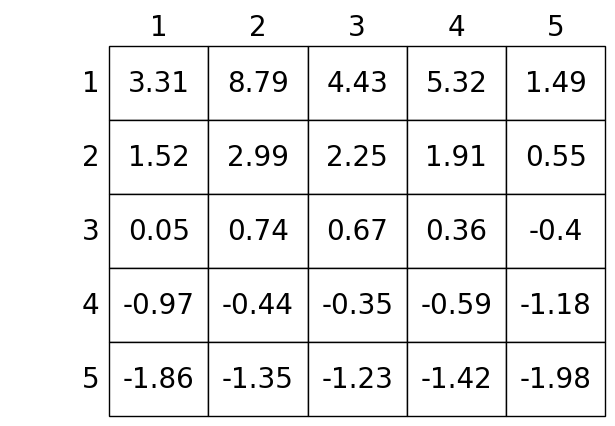

[[ 3.31  8.79  4.43  5.32  1.49]
 [ 1.52  2.99  2.25  1.91  0.55]
 [ 0.05  0.74  0.67  0.36 -0.4 ]
 [-0.97 -0.44 -0.35 -0.59 -1.18]
 [-1.86 -1.35 -1.23 -1.42 -1.98]]


In [18]:
import numpy as np
import os

GRID_HEIGHT = 5
GRID_WIDTH = 5

DISCOUNT_RATE = 0.9         # 감쇄율


# 그리드 월드에서 상태 가치 산출
def calculate_grid_world_state_values(env):
    ACTION_PROBABILITY = 0.25
    value_function = np.zeros(shape=(GRID_HEIGHT, GRID_WIDTH))

    # 가치 함수의 값들이 수렴할 때까지 반복
    while True:
        # value_function과 동일한 형태를 가지면서 값은 
        # 모두 0인 배열을 new_value_function에 저장
        new_value_function = np.zeros_like(value_function)

        for i in range(GRID_HEIGHT):
            for j in range(GRID_WIDTH):
                values = []
                # 주어진 상태에서 가능한 모든 행동들의 결과로 
                # 다음 상태들을 갱신
                for action in env.ACTIONS:
                    (next_i, next_j), reward, transition_prob \
                    = env.get_state_action_probability(
                        state=(i, j),
                        action=action
                    )

                    # Bellman-Equation, 벨만 방정식 적용
                    values.append(
                        ACTION_PROBABILITY * transition_prob * \
                        (reward + DISCOUNT_RATE * \
                         value_function[next_i, next_j])
                    )

                new_value_function[i, j] = np.sum(values)

        # 가치 함수 수렴 여부 판단 (0.0001 == 1e-4)
        if np.sum(np.abs(value_function - new_value_function)) < 1e-4:
            break

        # 가치 함수 갱신
        value_function = new_value_function

    return new_value_function

A_POSITION = (0, 1)         # 임의로 지정한 특별한 상태 A 좌표
B_POSITION = (0, 3)         # 임의로 지정한 특별한 상태 B 좌표

A_PRIME_POSITION = (4, 1)   # 상태 A에서 행동시 도착할 위치 좌표
B_PRIME_POSITION = (2, 3)   # 상태 B에서 행동시 도착할 위치 좌표

def main():
    # 5x5 맵 생성
    env = GridWorld(
        height=GRID_HEIGHT,
        width=GRID_WIDTH,
        start_state=None,
        terminal_states=[],
        transition_reward=0.0,
        outward_reward=-1.0,
        warm_hole_states=[
            (A_POSITION, A_PRIME_POSITION, 10.0),
            (B_POSITION, B_PRIME_POSITION, 5.0)
        ]
    )

    state_values = calculate_grid_world_state_values(env)

    draw_grid_world_state_values_image(state_values, GRID_HEIGHT, GRID_WIDTH)

    with np.printoptions(precision=2, suppress=True):
        print(state_values)

if __name__ == '__main__':
    main()

GridWorldOptimalState

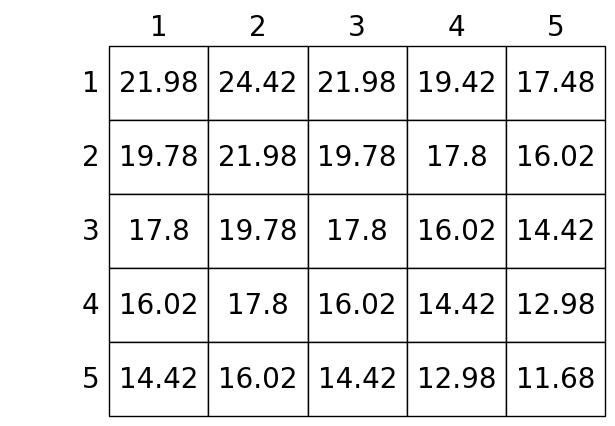

[[21.98 24.42 21.98 19.42 17.48]
 [19.78 21.98 19.78 17.8  16.02]
 [17.8  19.78 17.8  16.02 14.42]
 [16.02 17.8  16.02 14.42 12.98]
 [14.42 16.02 14.42 12.98 11.68]]


In [19]:
GRID_HEIGHT = 5
GRID_WIDTH = 5

DISCOUNT_RATE = 0.9      # 감쇄율

A_POSITION = (0, 1)         # 임의로 지정한 특별한 상태 A 좌표
B_POSITION = (0, 3)         # 임의로 지정한 특별한 상태 B 좌표

A_PRIME_POSITION = (4, 1)   # 상태 A에서 행동시 도착할 위치 좌표
B_PRIME_POSITION = (2, 3)   # 상태 B에서 행동시 도착할 위치 좌표


# 그리드 월드에서 최적 상태 가치 산출
def calculate_grid_world_optimal_state_values(env):
    value_function = np.zeros(shape=(GRID_HEIGHT, GRID_WIDTH))

    # 가치 함수의 값들이 수렴할 때까지 반복
    while True:
        # value_function과 동일한 형태를 가지면서 값은
        # 모두 0인 배열을 new_value_function에 저장
        new_value_function = np.zeros_like(value_function)

        for i in range(GRID_HEIGHT):
            for j in range(GRID_WIDTH):
                values = []
                # 주어진 상태에서 가능한 모든 행동들의 결과로
                # 다음 상태 및 보상 정보 갱신
                for action in env.ACTIONS:
                    (next_i, next_j), reward, prob \
                    = env.get_state_action_probability(
                        state=(i, j), action=action
                        )

                    # Bellman Optimality Equation, 벨만 최적 방정식 적용
                    values.append(
                        prob * (reward + DISCOUNT_RATE * \
                                value_function[next_i, next_j])
                    )

                # 새롭게 계산된 상태 가치 중 최대 상태 가치로 
                # 현재 상태의 가치 갱신
                new_value_function[i, j] = np.max(values)

        # 가치 함수 수렴 여부 판단
        if np.sum(np.abs(new_value_function - value_function)) < 1e-4:
            break

        value_function = new_value_function

    return new_value_function

def main():
    # 5x5 맵 생성
    env = GridWorld(
        height=GRID_HEIGHT,
        width=GRID_WIDTH,
        start_state=None,
        terminal_states=[],
        transition_reward=0,
        outward_reward=-1.0,
        warm_hole_states=[
            (A_POSITION, A_PRIME_POSITION, 10.0),
            (B_POSITION, B_PRIME_POSITION, 5.0)
        ]
    )

    optimal_state_values = calculate_grid_world_optimal_state_values(env)

    draw_grid_world_state_values_image(
        optimal_state_values, GRID_HEIGHT, GRID_WIDTH
    )

    with np.printoptions(precision=2, suppress=True):
        print(optimal_state_values)

if __name__ == '__main__':
    main()

GridWorldOptimalActionValueAndPolicy

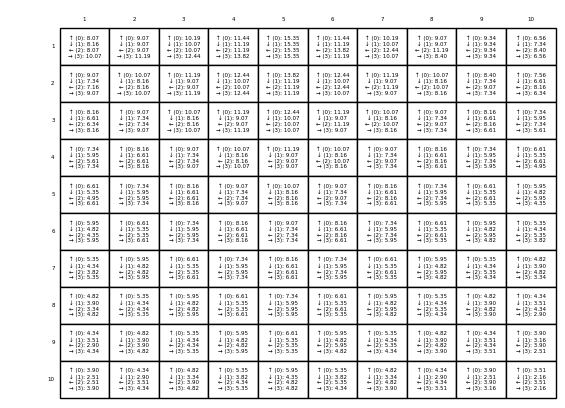

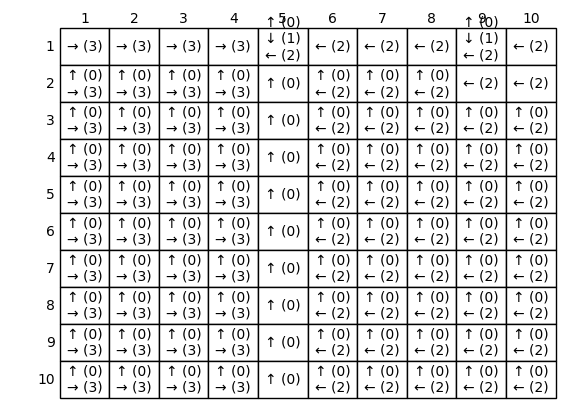

In [38]:
GRID_HEIGHT = 10
GRID_WIDTH = 10
DISCOUNT_RATE = 0.9      # 감쇄율

A_POSITION = (0, 4)         # 임의로 지정한 특별한 상태 A 좌표
B_POSITION = (0, 8)         # 임의로 지정한 특별한 상태 B 좌표

A_PRIME_POSITION = (9, 4)   # 상태 A에서 행동시 도착할 위치 좌표
B_PRIME_POSITION = (7, 8)   # 상태 B에서 행동시 도착할 위치 좌표


# 그리드 월드에서 최적 행동 가치 산출
def calculate_grid_world_optimal_action_values(env):
    action_value_function = np.zeros(
        shape=(GRID_HEIGHT, GRID_WIDTH, env.NUM_ACTIONS)
    )

    # 행동 가치 테이블의 값들이 수렴할 때까지 반복
    while True:
        # action_value_function과 동일한 형태를 가지면서 값은
        # 모두 0인 배열을 new_action_value_function에 저장
        new_action_value_function = np.zeros_like(action_value_function)

        for i in range(GRID_HEIGHT):
            for j in range(GRID_WIDTH):
                # 주어진 상태에서 가능한 모든 행동들의 결과로 
                # 다음 상태 및 보상 정보 갱신
                for action in env.ACTIONS:
                    (next_i, next_j), reward, prob \
                    = env.get_state_action_probability(
                        state=(i, j), action=action
                    )

                    # Bellman Optimality Equation, 벨만 최적 방정식 적용
                    # 새로운 행동 가치 갱신
                    new_action_value_function[i, j, action] = \
                        prob * (reward + DISCOUNT_RATE * \
                        np.max(action_value_function[next_i, next_j, :]))

        # 행동 가치 테이블 수렴 여부 판단
        if np.sum(np.abs(new_action_value_function - action_value_function)) < 1e-4:
            break

        action_value_function = new_action_value_function

    return new_action_value_function

def calculate_optimal_policy(optimal_action_value):
    optimal_policy = dict()
    for i in range(GRID_HEIGHT):
        for j in range(GRID_WIDTH):
            indices = [idx for idx, value_ 
                       in enumerate(optimal_action_value[i, j, :]) if
                       value_ == np.max(optimal_action_value[i, j, :])]
            optimal_policy[(i, j)] = indices

    return optimal_policy

def main():
    # 5x5 맵 생성
    env = GridWorld(
        height=GRID_HEIGHT,
        width=GRID_WIDTH,
        start_state=None,
        terminal_states=[],
        transition_reward=0,
        outward_reward=-1.0,
        warm_hole_states=[
            (A_POSITION, A_PRIME_POSITION, 10.0),
            (B_POSITION, B_PRIME_POSITION, 5.0)
        ]
    )

    optimal_action_values = calculate_grid_world_optimal_action_values(env)

    draw_grid_world_action_values_image(
        optimal_action_values, GRID_HEIGHT, GRID_WIDTH,
        env.NUM_ACTIONS, env.ACTION_SYMBOLS
    )

    print()

    optimal_policy = calculate_optimal_policy(optimal_action_values)
    draw_grid_world_optimal_policy_image(
        optimal_policy, GRID_HEIGHT, GRID_WIDTH, env.ACTION_SYMBOLS
    )

if __name__ == '__main__':
    main()

ValueIteration

[[[ 가치 반복 시작! ]]]
*** 가치 평가 [수렴까지 반복 횟수: 10] ***

*** 정책 셋업 완료 ***

[[ 0. -1. -2. -3. -4. -5. -6. -7. -8. -9.]
 [-1. -2. -3. -4. -5. -6. -7. -8. -9. -8.]
 [-2. -3. -4. -5. -6. -7. -8. -9. -8. -7.]
 [-3. -4. -5. -6. -7. -8. -9. -8. -7. -6.]
 [-4. -5. -6. -7. -8. -9. -8. -7. -6. -5.]
 [-5. -6. -7. -8. -9. -8. -7. -6. -5. -4.]
 [-6. -7. -8. -9. -8. -7. -6. -5. -4. -3.]
 [-7. -8. -9. -8. -7. -6. -5. -4. -3. -2.]
 [-8. -9. -8. -7. -6. -5. -4. -3. -2. -1.]
 [-9. -8. -7. -6. -5. -4. -3. -2. -1.  0.]]


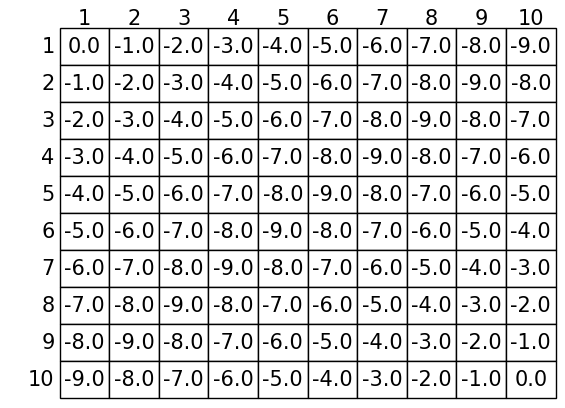

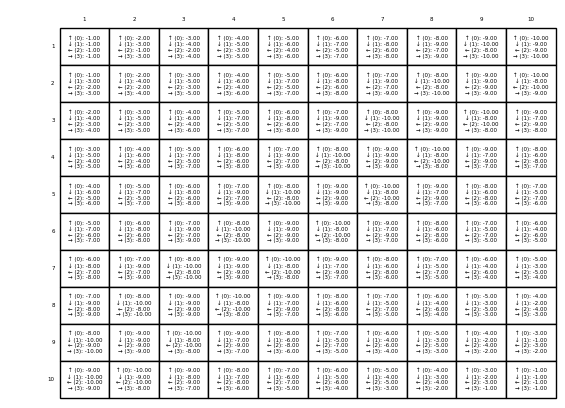

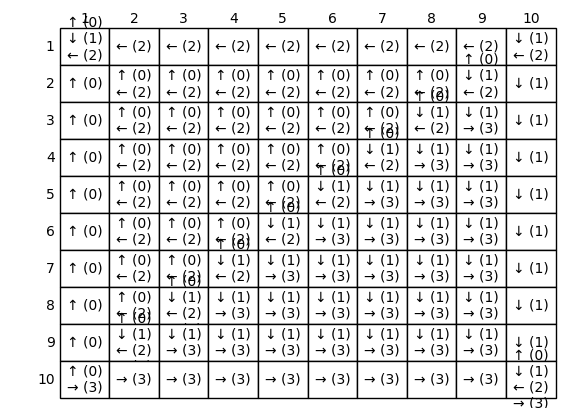

In [27]:
import numpy as np

GRID_HEIGHT = 10
GRID_WIDTH = 10
TERMINAL_STATES = [(0, 0), (GRID_HEIGHT-1, GRID_WIDTH-1)]

DISCOUNT_RATE = 1.0
THETA_1 = 0.0001


# 가치 반복 클래스
class ValueIteration:
    def __init__(self, env):
        self.env = env
        self.state_values = None
        self.policy = np.empty([GRID_HEIGHT, GRID_WIDTH, self.env.NUM_ACTIONS])

        for i in range(GRID_HEIGHT):
            for j in range(GRID_WIDTH):
                for action in self.env.ACTIONS:
                    if (i, j) in TERMINAL_STATES:
                        self.policy[i][j][action] = 0.00
                    else:
                        self.policy[i][j][action] = 0.25

    # 가치 평가 함수
    def value_evaluation(self):
        # 상태-가치 함수 초기화
        state_values = np.zeros((GRID_HEIGHT, GRID_WIDTH))

        # 가치 함수의 값들이 수렴할 때까지 반복
        iter_num = 0
        while True:
            old_state_values = state_values.copy()

            for i in range(GRID_HEIGHT):
                for j in range(GRID_WIDTH):
                    if (i, j) in TERMINAL_STATES:
                        state_values[i][j] = 0.0
                    else:
                        values = []
                        for action in self.env.ACTIONS:
                            (next_i, next_j), reward, prob \
                            = self.env.get_state_action_probability(
                                state=(i, j), action=action
                            )

                            # Bellman-Equation, 벨만 방정식 적용
                            values.append(
                                prob * (reward + \
                                DISCOUNT_RATE * state_values[next_i, next_j])
                            )

                        state_values[i][j] = np.max(values)

            iter_num += 1

            # 갱신되는 값이 THETA_1(=0.0001)을 기준으로 수렴하는지 판정
            delta_value = np.sum(np.absolute(old_state_values - state_values))
            if delta_value < THETA_1:
                break

        self.state_values = state_values

        return iter_num

    # 최적 정책 산출 함수
    def policy_setup(self):
        for i in range(GRID_HEIGHT):
            for j in range(GRID_WIDTH):
                if (i, j) in TERMINAL_STATES:
                    for action in self.env.ACTIONS:
                        self.policy[i][j][action] = 0.0
                else:
                    q_func = []
                    for action in self.env.ACTIONS:
                        (next_i, next_j), reward, prob \
                        = self.env.get_state_action_probability(
                            state=(i, j), action=action
                        )
                        q_func.append(
                            prob * (reward + DISCOUNT_RATE * \
                                    self.state_values[next_i, next_j])
                        )

                    self.policy[i][j] = softmax(q_func)

    # 가치 반복 함수
    def start_iteration(self):
        print("[[[ 가치 반복 시작! ]]]")

        iter_num_policy_evaluation = self.value_evaluation()
        print("*** 가치 평가 [수렴까지 반복 횟수: {0}] ***".format(
            iter_num_policy_evaluation)
        )

        print()
        self.policy_setup()
        print("*** 정책 셋업 완료 ***")
        print()

        return self.state_values, self.policy

    def calculate_optimal_policy(self):
        optimal_policy = dict()
        for i in range(GRID_HEIGHT):
            for j in range(GRID_WIDTH):
                indices = [idx for idx, value_ 
                           in enumerate(self.policy[i, j, :]) if
                           value_ == np.max(self.policy[i, j, :])]
                optimal_policy[(i, j)] = indices

        return optimal_policy

    def calculate_grid_world_optimal_action_values(self):
        action_value_function = np.zeros(
            (GRID_HEIGHT, GRID_WIDTH, self.env.NUM_ACTIONS)
        )
        for i in range(GRID_HEIGHT):
            for j in range(GRID_WIDTH):
                # 주어진 상태에서 가능한 모든 행동들의 결과로 
                # 다음 상태 및 보상 정보 갱신
                for action in self.env.ACTIONS:
                    (next_i, next_j), reward, prob \
                    = self.env.get_state_action_probability(
                        state=(i, j), action=action
                    )

                    action_value_function[i, j, action] = \
                        prob * (reward + DISCOUNT_RATE * \
                                self.state_values[next_i, next_j])

        return action_value_function

def value_iteration_main():
    # 그리드 월드 환경 객체 생성
    env = GridWorld(
        height=GRID_HEIGHT,
        width=GRID_WIDTH,
        start_state=(0, 0),
        terminal_states=TERMINAL_STATES,
        transition_reward=-1.0,
        terminal_reward=-1.0,
        outward_reward=-1.0
    )
    env.reset()

    VI = ValueIteration(env)
    VI.start_iteration()

    print(VI.state_values)

    draw_grid_world_state_values_image(
        VI.state_values,
        GRID_HEIGHT, GRID_WIDTH
    )

    draw_grid_world_action_values_image(
        VI.calculate_grid_world_optimal_action_values(),
        GRID_HEIGHT, GRID_WIDTH,
        env.NUM_ACTIONS,
        env.ACTION_SYMBOLS
    )

    draw_grid_world_optimal_policy_image(
        VI.calculate_optimal_policy(),
        GRID_HEIGHT, GRID_WIDTH, env.ACTION_SYMBOLS
    )

if __name__ == '__main__':
    value_iteration_main()

PolicyIteration

[[[ 정책 반복 시작! ]]]
*** 정책 평가 [수렴까지 반복 횟수: 75] ***
*** 정책 개선 [에러 값: 11.58701] ***
*** 정책의 안정(Stable) 여부: False, 반복 횟수: 1 ***

*** 정책 평가 [수렴까지 반복 횟수: 19] ***
*** 정책 개선 [에러 값: 4.16469] ***
*** 정책의 안정(Stable) 여부: False, 반복 횟수: 2 ***

*** 정책 평가 [수렴까지 반복 횟수: 24] ***
*** 정책 개선 [에러 값: 1.74766] ***
*** 정책의 안정(Stable) 여부: False, 반복 횟수: 3 ***

*** 정책 평가 [수렴까지 반복 횟수: 22] ***
*** 정책 개선 [에러 값: 0.90381] ***
*** 정책의 안정(Stable) 여부: False, 반복 횟수: 4 ***

*** 정책 평가 [수렴까지 반복 횟수: 22] ***
*** 정책 개선 [에러 값: 0.38731] ***
*** 정책의 안정(Stable) 여부: False, 반복 횟수: 5 ***

*** 정책 평가 [수렴까지 반복 횟수: 22] ***
*** 정책 개선 [에러 값: 0.14481] ***
*** 정책의 안정(Stable) 여부: False, 반복 횟수: 6 ***

*** 정책 평가 [수렴까지 반복 횟수: 22] ***
*** 정책 개선 [에러 값: 0.06276] ***
*** 정책의 안정(Stable) 여부: False, 반복 횟수: 7 ***

*** 정책 평가 [수렴까지 반복 횟수: 22] ***
*** 정책 개선 [에러 값: 0.02923] ***
*** 정책의 안정(Stable) 여부: False, 반복 횟수: 8 ***

*** 정책 평가 [수렴까지 반복 횟수: 22] ***
*** 정책 개선 [에러 값: 0.01157] ***
*** 정책의 안정(Stable) 여부: False, 반복 횟수: 9 ***

*** 정책 평가 [수렴까지 반복 횟수: 22] ***
*** 정

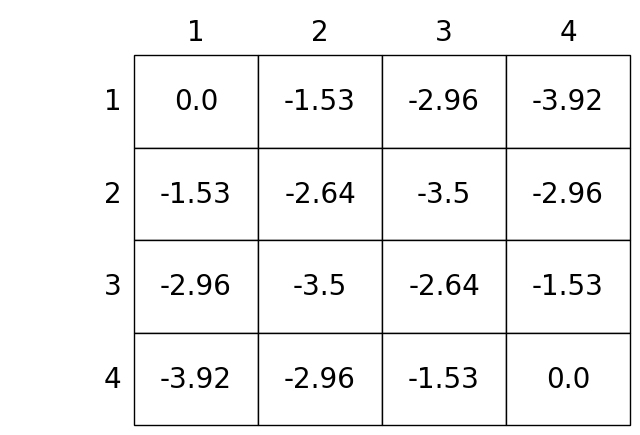

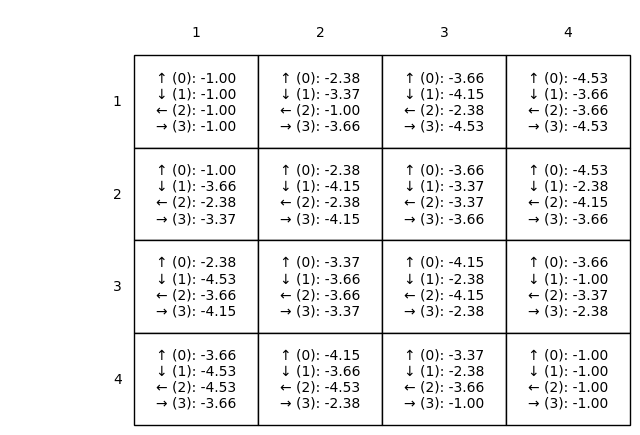

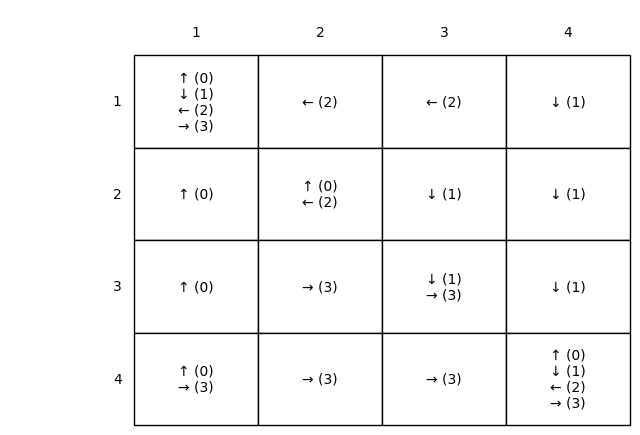

In [ ]:
import numpy as np
import os

GRID_HEIGHT = 10
GRID_WIDTH = 10
TERMINAL_STATES = [(0, 0), (GRID_HEIGHT-1, GRID_WIDTH-1)]

DISCOUNT_RATE = 0.9

THETA_1 = 0.0001
THETA_2 = 0.0001

# 정책 반복 클래스
class PolicyIteration:
    def __init__(self, env):
        self.env = env
        self.state_values = None
        self.policy = np.empty([GRID_HEIGHT, GRID_WIDTH, self.env.NUM_ACTIONS])

        # 모든 상태에서 수행 가능한 행동에 맞춰 임의의 정책을 생성함
        # 초기에 각 행동의 선택 확률은 모두 같음
        for i in range(GRID_HEIGHT):
            for j in range(GRID_WIDTH):
                for action in self.env.ACTIONS:
                    if (i, j) in TERMINAL_STATES:
                        self.policy[i][j][action] = 0.00
                    else:
                        self.policy[i][j][action] = 0.25
                        
    # 정책 평가 함수
    def policy_evaluation(self):
        # 임시 상태-가치 저장 변수 초기화
        state_values = np.zeros((GRID_HEIGHT, GRID_WIDTH))

        # 가치 함수의 값들이 수렴할 때까지 반복
        iter_num = 0
        while True:
            # 현재 상태 가치 저장
            old_state_values = state_values.copy()

            for i in range(GRID_HEIGHT):
                for j in range(GRID_WIDTH):
                    if (i, j) in TERMINAL_STATES:
                        state_values[i][j] = 0.0
                    else:
                        values = []
                        for action in self.env.ACTIONS:
                            (next_i, next_j), reward, prob \
                            = self.env.get_state_action_probability(
                                state=(i, j), action=action
                            )

                            # Bellman-Equation, 벨만 방정식 적용
                            values.append(
                                self.policy[i, j, action] * prob \
                                * (reward + DISCOUNT_RATE * \
                                   old_state_values[next_i, next_j])
                            )

                        state_values[i][j] = np.sum(values)

            iter_num += 1

            # 갱신되는 값이 THETA_1(=0.0001)을 기준으로 수렴하는지 판정
            delta_value = np.sum(np.absolute(old_state_values - state_values))
            if delta_value < THETA_1:
                break

        self.state_values = state_values

        return iter_num

    # 정책 개선 함수
    def policy_improvement(self):
        new_policy = np.empty([GRID_HEIGHT, GRID_WIDTH, self.env.NUM_ACTIONS])

        is_policy_stable = True

        # 행동-가치 함수 생성
        for i in range(GRID_HEIGHT):
            for j in range(GRID_WIDTH):
                if (i, j) in TERMINAL_STATES:
                    for action in self.env.ACTIONS:
                        new_policy[i][j][action] = 0.00
                else:
                    q_func = []
                    for action in self.env.ACTIONS:
                        (next_i, next_j), reward, prob \
                        = self.env.get_state_action_probability(
                            state=(i, j), action=action
                        )
                        q_func.append(
                            prob * (reward + DISCOUNT_RATE \
                            * self.state_values[next_i, next_j])
                        )

                    new_policy[i, j, :] = softmax(q_func)

        error = np.sum(np.absolute(self.policy - new_policy))

        if error > THETA_2:
            is_policy_stable = False

        self.policy = new_policy

        return is_policy_stable, error

    # 정책 반복 함수
    def start_iteration(self):
        iter_num = 0

        # 정책의 안정성 검증
        is_policy_stable = False

        print("[[[ 정책 반복 시작! ]]]")

        while not is_policy_stable:
            iter_num_policy_evaluation = self.policy_evaluation()
            print("*** 정책 평가 [수렴까지 반복 횟수: {0}] ***".format(
                iter_num_policy_evaluation
            ))

            is_policy_stable, error = self.policy_improvement()
            print("*** 정책 개선 [에러 값: {0:7.5f}] ***".format(error))

            iter_num += 1
            print("*** 정책의 안정(Stable) 여부: {0}, 반복 횟수: {1} ***\n".format(
                is_policy_stable,
                iter_num
            ))
        print("[[[ 정책 반복 종료! ]]]\n\n")

        return self.state_values, self.policy

    def calculate_optimal_policy(self):
        optimal_policy = dict()
        for i in range(GRID_HEIGHT):
            for j in range(GRID_WIDTH):
                indices = [idx for idx, value_ 
                           in enumerate(self.policy[i, j, :]) if
                           value_ == np.max(self.policy[i, j, :])]
                optimal_policy[(i, j)] = indices

        return optimal_policy

    def calculate_grid_world_optimal_action_values(self):
        action_value_function = np.zeros((GRID_HEIGHT, GRID_WIDTH, self.env.NUM_ACTIONS))
        for i in range(GRID_HEIGHT):
            for j in range(GRID_WIDTH):
                # 주어진 상태에서 가능한 모든 행동들의 결과로 
                # 다음 상태 및 보상 정보 갱신
                for action in self.env.ACTIONS:
                    (next_i, next_j), reward, prob \
                    = self.env.get_state_action_probability(
                        state=(i, j), action=action
                    )

                    action_value_function[i, j, action] = \
                        prob * (reward + DISCOUNT_RATE \
                                * self.state_values[next_i, next_j])

        return action_value_function

def main():
    # 그리드 월드 환경 객체 생성
    env = GridWorld(
        height=GRID_HEIGHT,
        width=GRID_WIDTH,
        start_state=(0, 0),
        terminal_states=TERMINAL_STATES,
        transition_reward=-1.0,
        terminal_reward=-1.0,
        outward_reward=-1.0
    )
    env.reset()

    PI = PolicyIteration(env)
    PI.start_iteration()

    print(PI.state_values)

    draw_grid_world_state_values_image(
        PI.state_values, GRID_HEIGHT, GRID_WIDTH
    )

    draw_grid_world_action_values_image(
        PI.calculate_grid_world_optimal_action_values(),
        GRID_HEIGHT, GRID_WIDTH, env.NUM_ACTIONS, env.ACTION_SYMBOLS
    )

    draw_grid_world_optimal_policy_image(
        PI.calculate_optimal_policy(),
        GRID_HEIGHT, GRID_WIDTH, env.ACTION_SYMBOLS
    )

if __name__ == "__main__":
    main()